In [1]:
# ===== Cell 0: installs (first run only) =====
!pip -q install --upgrade pip

# (PyTorch is preinstalled on Kaggle)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 21.2 MB/s eta 0:00:0000:010:01


In [2]:
# ===== Cell 1: imports, config, seeds =====
import os, math, glob, time, json, random, shutil, re, threading
from dataclasses import dataclass
from pathlib import Path
from typing import List, Tuple

import numpy as np
from PIL import Image
import cv2

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.amp import autocast, GradScaler
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, utils as vutils

from tqdm import tqdm

# Reproducibility
def set_seed(seed=42):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
set_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device)

# Kaggle paths
DATA_ROOT = Path('/kaggle/input/person-face-sketches')  # <-- dataset path on Kaggle after adding dataset to notebook
WORK_DIR  = Path('/kaggle/working')
CKPT_DIR  = WORK_DIR/'checkpoints'; CKPT_DIR.mkdir(parents=True, exist_ok=True)
SAMPLES_DIR = WORK_DIR/'samples'; SAMPLES_DIR.mkdir(parents=True, exist_ok=True)

# Mixed precision
USE_AMP = True

# Simple logger
def log(*args): print(time.strftime("[%H:%M:%S]"), *args)

# Safety: show GPU memory
!nvidia-smi -L


Device: cuda
GPU 0: Tesla T4 (UUID: GPU-6d1b3a5e-eb44-b7e4-2791-65e731a94fcb)
GPU 1: Tesla T4 (UUID: GPU-e3c96e76-13e0-8d24-2168-8009fe9b71a7)


In [3]:
# ===== Cell 2 (patched): data discovery + torchvision-only transforms =====
import re, cv2
from pathlib import Path
from typing import List, Tuple
from PIL import Image
from torchvision import transforms
from torch.utils.data import Dataset

def find_domains(root: Path) -> Tuple[Path, Path]:
    cands = [p for p in root.rglob('*') if p.is_dir() and any(p.iterdir())]
    if not cands:
        raise FileNotFoundError("No subfolders found inside dataset root.")
    def score_face(name):  return int(bool(re.search(r'(face|photo|real)', name, re.I)))
    def score_sketch(name):return int('sketch' in name.lower())
    faces = [p for p in cands if score_face(p.name) and not score_sketch(p.name)]
    sketches = [p for p in cands if score_sketch(p.name) and not score_face(p.name)]
    if faces and sketches:
        face_dir = max(faces, key=lambda x: len(x.as_posix()))
        sketch_dir = max(sketches, key=lambda x: len(x.as_posix()))
        return face_dir, sketch_dir
    sizes = [(p, sum(1 for _ in p.rglob('*') if _.is_file())) for p in cands]
    sizes.sort(key=lambda x: x[1], reverse=True)
    if len(sizes) < 2:
        raise RuntimeError("Need at least 2 non-empty folders (faces & sketches).")
    return sizes[0][0], sizes[1][0]

DATA_ROOT = Path('/kaggle/input/person-face-sketches')
FACE_DIR, SKETCH_DIR = find_domains(DATA_ROOT)
print("FACE_DIR:", FACE_DIR)
print("SKETCH_DIR:", SKETCH_DIR)

IMG_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}
def list_images(root: Path) -> List[Path]:
    return [p for p in root.rglob('*') if p.suffix.lower() in IMG_EXTS]

IMG_SIZE = 256

class TorchDictTransform:
    """Mimics albumentations API: __call__(image=np.ndarray)->{'image': tensor}."""
    def __init__(self, train=True):
        if train:
            tf = transforms.Compose([
                transforms.Resize(IMG_SIZE + 30, interpolation=transforms.InterpolationMode.BICUBIC),
                transforms.RandomCrop(IMG_SIZE),
                transforms.RandomHorizontalFlip(0.5),
                transforms.ToTensor(),
                transforms.Normalize(mean=(0.5,0.5,0.5), std=(0.5,0.5,0.5)),
            ])
        else:
            tf = transforms.Compose([
                transforms.Resize(IMG_SIZE, interpolation=transforms.InterpolationMode.BICUBIC),
                transforms.CenterCrop(IMG_SIZE),
                transforms.ToTensor(),
                transforms.Normalize(mean=(0.5,0.5,0.5), std=(0.5,0.5,0.5)),
            ])
        self.tf = tf
    def __call__(self, image):
        # input: np.ndarray RGB (H,W,3)
        pil = Image.fromarray(image)
        t = self.tf(pil)
        return {"image": t}

def build_transform(train=True):
    return TorchDictTransform(train=train)

class UnpairedImageDataset(Dataset):
    def __init__(self, dirA: Path, dirB: Path, transform, max_items_per_domain=None):
        self.A_paths = list_images(dirA)
        self.B_paths = list_images(dirB)
        if max_items_per_domain:
            self.A_paths = self.A_paths[:max_items_per_domain]
            self.B_paths = self.B_paths[:max_items_per_domain]
        if len(self.A_paths)==0 or len(self.B_paths)==0:
            raise RuntimeError("Empty domain folders. Check dataset paths.")
        self.transform = transform

    def __len__(self): return max(len(self.A_paths), len(self.B_paths))

    def __getitem__(self, idx):
        A_path = self.A_paths[idx % len(self.A_paths)]
        B_path = self.B_paths[random.randint(0, len(self.B_paths)-1)]
        A_img = cv2.cvtColor(cv2.imread(str(A_path)), cv2.COLOR_BGR2RGB)
        B_img = cv2.cvtColor(cv2.imread(str(B_path)), cv2.COLOR_BGR2RGB)
        A = self.transform(image=A_img)['image']
        B = self.transform(image=B_img)['image']
        return A, B


FACE_DIR: /kaggle/input/person-face-sketches/train/photos
SKETCH_DIR: /kaggle/input/person-face-sketches/train/sketches


In [4]:
# ===== Cell 3: CycleGAN model definitions =====

class ResnetBlock(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.block = nn.Sequential(
            nn.ReflectionPad2d(1),
            nn.Conv2d(dim, dim, 3, 1, 0, bias=False),
            nn.InstanceNorm2d(dim, affine=False),
            nn.ReLU(inplace=True),
            nn.ReflectionPad2d(1),
            nn.Conv2d(dim, dim, 3, 1, 0, bias=False),
            nn.InstanceNorm2d(dim, affine=False)
        )
    def forward(self, x): return x + self.block(x)

class ResnetGenerator(nn.Module):
    def __init__(self, in_c=3, out_c=3, ngf=64, n_blocks=9):
        super().__init__()
        model = [
            nn.ReflectionPad2d(3),
            nn.Conv2d(in_c, ngf, 7, 1, 0, bias=False),
            nn.InstanceNorm2d(ngf, affine=False),
            nn.ReLU(inplace=True),
        ]
        # down
        c = ngf
        for _ in range(2):
            model += [
                nn.Conv2d(c, c*2, 3, 2, 1, bias=False),
                nn.InstanceNorm2d(c*2, affine=False),
                nn.ReLU(inplace=True),
            ]
            c *= 2
        # res blocks
        for _ in range(n_blocks):
            model += [ResnetBlock(c)]
        # up
        for _ in range(2):
            model += [
                nn.ConvTranspose2d(c, c//2, 3, 2, 1, output_padding=1, bias=False),
                nn.InstanceNorm2d(c//2, affine=False),
                nn.ReLU(inplace=True),
            ]
            c //= 2
        model += [
            nn.ReflectionPad2d(3),
            nn.Conv2d(c, out_c, 7, 1, 0),
            nn.Tanh()
        ]
        self.model = nn.Sequential(*model)
    def forward(self, x): return self.model(x)

class PatchDiscriminator(nn.Module):
    def __init__(self, in_c=3, ndf=64, n_layers=3):
        super().__init__()
        kw, padw = 4, 1
        seq = [nn.Conv2d(in_c, ndf, kw, 2, padw), nn.LeakyReLU(0.2, inplace=True)]
        nf_mult = 1
        for n in range(1, n_layers):
            nf_prev = nf_mult; nf_mult = min(2**n, 8)
            seq += [
                nn.Conv2d(ndf*nf_prev, ndf*nf_mult, kw, 2, padw, bias=False),
                nn.InstanceNorm2d(ndf*nf_mult, affine=False),
                nn.LeakyReLU(0.2, inplace=True)
            ]
        nf_prev = nf_mult; nf_mult = min(2**n_layers, 8)
        seq += [
            nn.Conv2d(ndf*nf_prev, ndf*nf_mult, kw, 1, padw, bias=False),
            nn.InstanceNorm2d(ndf*nf_mult, affine=False),
            nn.LeakyReLU(0.2, inplace=True)
        ]
        seq += [nn.Conv2d(ndf*nf_mult, 1, kw, 1, padw)]
        self.model = nn.Sequential(*seq)
    def forward(self, x): return self.model(x)

# Image replay buffer helps stabilize training
class ImagePool:
    def __init__(self, pool_size=50):
        self.pool_size = pool_size
        self.images = []
    def query(self, images):
        result = []
        for img in images:
            img = img.detach()
            if len(self.images) < self.pool_size:
                self.images.append(img)
                result.append(img)
            else:
                if random.random() > 0.5:
                    idx = random.randrange(self.pool_size)
                    tmp = self.images[idx].clone()
                    self.images[idx] = img
                    result.append(tmp)
                else:
                    result.append(img)
        return torch.stack(result, 0)


In [5]:
# ===== Cell 4: train config and helpers (multi-GPU safe) =====
import torch, shutil
import torch.nn as nn
from dataclasses import dataclass
from tqdm import tqdm
from torchvision import utils as vutils
from torch.amp import autocast, GradScaler   # new AMP API

@dataclass
class TrainConfig:
    epochs: int = 10
    batch_size: int = 8
    lr: float = 2e-4
    beta1: float = 0.5
    beta2: float = 0.999
    lambda_cycle: float = 10.0
    lambda_id: float = 0.5
    num_workers: int = 4
    max_items_per_domain: int = None
    save_every_epoch: bool = True
    resume: bool = True
    lr_decay_start_epoch: int = 15
    use_amp: bool = torch.cuda.is_available()

cfg = TrainConfig()

# ----- utils to handle DataParallel cleanly -----
def sd(model):
    """Return a clean (unwrapped) state_dict whether model is wrapped or not."""
    return model.module.state_dict() if isinstance(model, nn.DataParallel) else model.state_dict()

def maybe_strip_module(state_dict):
    """If keys start with 'module.', strip it so we can load into unwrapped models too."""
    if len(state_dict) == 0: return state_dict
    if next(iter(state_dict.keys())).startswith("module."):
        return {k[len("module."):]: v for k, v in state_dict.items()}
    return state_dict

def save_checkpoint(epoch, G_AB, G_BA, D_A, D_B, opt_G, opt_D, scaler, out_dir=CKPT_DIR):
    """Full checkpoint (models + optimizers + scaler), DataParallel-safe."""
    state = {
        'epoch': epoch,
        'G_AB': sd(G_AB),
        'G_BA': sd(G_BA),
        'D_A':  sd(D_A),
        'D_B':  sd(D_B),
        'opt_G': opt_G.state_dict(),
        'opt_D': opt_D.state_dict(),
        'scaler': scaler.state_dict() if scaler is not None else None,
        'cfg': cfg.__dict__
    }
    path = out_dir / f'cyclegan_epoch_{epoch:03d}.pt'
    torch.save(state, path)
    log(f"✅ Saved checkpoint: {path}")

def save_models_epoch(epoch, G_AB, G_BA, D_A, D_B, out_dir=CKPT_DIR):
    """Save only model weights + 'latest' aliases, DataParallel-safe."""
    torch.save(sd(G_AB), out_dir / f'G_AB_epoch_{epoch:03d}.pt')
    torch.save(sd(G_BA), out_dir / f'G_BA_epoch_{epoch:03d}.pt')
    torch.save(sd(D_A),  out_dir / f'D_A_epoch_{epoch:03d}.pt')
    torch.save(sd(D_B),  out_dir / f'D_B_epoch_{epoch:03d}.pt')

    torch.save({
        'epoch': epoch,
        'G_AB': sd(G_AB),
        'G_BA': sd(G_BA),
        'D_A':  sd(D_A),
        'D_B':  sd(D_B),
    }, out_dir / f'models_epoch_{epoch:03d}.pt')

    # Latest copies
    for name in ['G_AB', 'G_BA', 'D_A', 'D_B', 'models']:
        src = out_dir / f'{name}_epoch_{epoch:03d}.pt'
        dst = out_dir / f'{name}_latest.pt'
        shutil.copy(src, dst)

def latest_checkpoint(out_dir=CKPT_DIR):
    ckpts = sorted(out_dir.glob('cyclegan_epoch_*.pt'))
    return ckpts[-1] if ckpts else None

def make_linear_decay(optimizer, start_epoch, total_epochs):
    def lr_lambda(cur_epoch):
        if cur_epoch < start_epoch: return 1.0
        return 1.0 - (cur_epoch - start_epoch) / max(1, total_epochs - start_epoch)
    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

@torch.no_grad()
def save_sample_epoch(epoch, data_iter, G_AB, G_BA, n=4):
    """Visualize A→B and B→A samples each epoch (works with DataParallel)."""
    G_AB.eval(); G_BA.eval()
    A_list, B_list = [], []
    for _ in range(n):
        try:
            A, B = next(data_iter)
        except StopIteration:
            break
        A_list.append(A.to(device))
        B_list.append(B.to(device))
    if not A_list: return
    A = torch.cat(A_list, 0); B = torch.cat(B_list, 0)
    fake_B = G_AB(A)
    rec_A  = G_BA(fake_B)
    fake_A = G_BA(B)
    rec_B  = G_AB(fake_A)

    def denorm(x): return (x*0.5 + 0.5).clamp(0,1)
    grid1 = vutils.make_grid(torch.cat([denorm(A), denorm(fake_B), denorm(rec_A)], 0), nrow=n)
    grid2 = vutils.make_grid(torch.cat([denorm(B), denorm(fake_A), denorm(rec_B)], 0), nrow=n)
    vutils.save_image(grid1, SAMPLES_DIR/f'epoch_{epoch:03d}_A2B.png')
    vutils.save_image(grid2, SAMPLES_DIR/f'epoch_{epoch:03d}_B2A.png')
    log(f"🖼️ Saved samples for epoch {epoch}")


def export_checkpoints_zip(name="cyclegan_artifacts"):
    """
    Creates a ZIP with checkpoints, latest weights, and samples under /kaggle/working/.
    You can download it from the Kaggle 'Files' sidebar.
    """
    export_dir = WORK_DIR / f"{name}"
    export_dir.mkdir(exist_ok=True)
    # Collect folders/files
    for p in [CKPT_DIR, SAMPLES_DIR]:
        if p.exists():
            dst = export_dir / p.name
            if dst.exists():
                shutil.rmtree(dst)
            shutil.copytree(p, dst)
    # Make the zip
    zip_path = WORK_DIR / f"{name}.zip"
    if zip_path.exists():
        zip_path.unlink()
    shutil.make_archive(str(zip_path.with_suffix('')), 'zip', export_dir)
    log("📦 Export ready:", zip_path)
    return zip_path

import torch.nn as nn

def load_sd_into(model, state_dict, strict=True):
    # strip "module." if present in the saved dict
    def _strip_module(sd):
        if not sd: return sd
        k0 = next(iter(sd.keys()))
        return {k.replace('module.', '', 1): v for k, v in sd.items()} if k0.startswith('module.') else sd

    sd = _strip_module(state_dict)
    if isinstance(model, nn.DataParallel):
        model.module.load_state_dict(sd, strict=strict)   # <-- load into the wrapped module
    else:
        model.load_state_dict(sd, strict=strict)




In [6]:
# ===== Cell 5: Full training function (multi-GPU + AMP + resume + per-epoch .pt saves) =====
import json
import torch.nn as nn
from torch.utils.data import DataLoader
from torch.amp import autocast, GradScaler

def train():
    # ---- Dataset / loader ----
    train_tf = build_transform(train=True)
    ds = UnpairedImageDataset(
        FACE_DIR, SKETCH_DIR,
        transform=train_tf,
        max_items_per_domain=cfg.max_items_per_domain
    )
    dl = DataLoader(
        ds,
        batch_size=cfg.batch_size,
        shuffle=True,
        num_workers=cfg.num_workers,
        drop_last=True,
        pin_memory=torch.cuda.is_available()
    )

    # ---- Models ----
    G_AB = ResnetGenerator().to(device)   # face → sketch
    G_BA = ResnetGenerator().to(device)   # sketch → face
    D_A  = PatchDiscriminator().to(device)
    D_B  = PatchDiscriminator().to(device)

    # ---- Multi-GPU ----
    if torch.cuda.is_available() and torch.cuda.device_count() > 1:
        log(f"🚀 Using DataParallel on {torch.cuda.device_count()} GPUs")
        G_AB = nn.DataParallel(G_AB)
        G_BA = nn.DataParallel(G_BA)
        D_A  = nn.DataParallel(D_A)
        D_B  = nn.DataParallel(D_B)

    # ---- Optimizers ----
    opt_G = torch.optim.Adam(
        list(G_AB.parameters()) + list(G_BA.parameters()),
        lr=cfg.lr, betas=(cfg.beta1, cfg.beta2)
    )
    opt_D = torch.optim.Adam(
        list(D_A.parameters()) + list(D_B.parameters()),
        lr=cfg.lr, betas=(cfg.beta1, cfg.beta2)
    )

    # ---- Losses, buffers, AMP ----
    adv_criterion = nn.MSELoss()
    l1_criterion  = nn.L1Loss()
    pool_A, pool_B = ImagePool(50), ImagePool(50)
    scaler = GradScaler('cuda', enabled=cfg.use_amp)

    # ---- LR schedulers ----
    sch_G = make_linear_decay(opt_G, cfg.lr_decay_start_epoch, cfg.epochs)
    sch_D = make_linear_decay(opt_D, cfg.lr_decay_start_epoch, cfg.epochs)

   # ---- Resume (supports cfg.resume_epoch) ----
    start_epoch = 1
    if cfg.resume:
        if hasattr(cfg, "resume_epoch") and cfg.resume_epoch is not None:
            ck = CKPT_DIR / f"cyclegan_epoch_{cfg.resume_epoch:03d}.pt"
            assert ck.exists(), f"Requested checkpoint not found: {ck}"
        else:
            ck = latest_checkpoint()
    
        if ck is not None:
            state = torch.load(ck, map_location=device)
    
            # DataParallel-safe loading
            load_sd_into(G_AB, state['G_AB'])
            load_sd_into(G_BA, state['G_BA'])
            load_sd_into(D_A,  state['D_A'])
            load_sd_into(D_B,  state['D_B'])
    
            opt_G.load_state_dict(state['opt_G'])
            opt_D.load_state_dict(state['opt_D'])
            if state.get('scaler'):
                scaler.load_state_dict(state['scaler'])
    
            start_epoch = state['epoch'] + 1
            log(f"🔁 Resumed from {ck.name} (start_epoch={start_epoch})")


    # ---- Fixed iterator for epoch samples ----
    fixed_iter = iter(DataLoader(
        ds, batch_size=cfg.batch_size, shuffle=True,
        num_workers=0, drop_last=True
    ))

    # ---- History file ----
    history_path = WORK_DIR / "train_history.json"
    if history_path.exists():
        try:
            train_history = json.load(open(history_path))
        except Exception:
            train_history = {"epoch": [], "G_loss": [], "D_loss": []}
    else:
        train_history = {"epoch": [], "G_loss": [], "D_loss": []}

    try:
        for epoch in range(start_epoch, cfg.epochs + 1):
            G_AB.train(); G_BA.train(); D_A.train(); D_B.train()
            pbar = tqdm(dl, desc=f"Epoch {epoch}/{cfg.epochs}", ncols=100)

            running_G, running_D, steps = 0.0, 0.0, 0

            for A, B in pbar:
                A, B = A.to(device), B.to(device)

                # === Generators ===
                opt_G.zero_grad(set_to_none=True)
                with autocast('cuda', enabled=cfg.use_amp):
                    fake_B = G_AB(A)
                    loss_G_AB_adv = adv_criterion(D_B(fake_B), torch.ones_like(D_B(fake_B)))

                    fake_A = G_BA(B)
                    loss_G_BA_adv = adv_criterion(D_A(fake_A), torch.ones_like(D_A(fake_A)))

                    rec_A = G_BA(fake_B)
                    rec_B = G_AB(fake_A)
                    loss_cycle = (l1_criterion(rec_A, A) + l1_criterion(rec_B, B)) * cfg.lambda_cycle

                    idt_A = G_BA(A)
                    idt_B = G_AB(B)
                    loss_id = (l1_criterion(idt_A, A) + l1_criterion(idt_B, B)) * cfg.lambda_cycle * cfg.lambda_id

                    loss_G = loss_G_AB_adv + loss_G_BA_adv + loss_cycle + loss_id

                scaler.scale(loss_G).backward()
                scaler.step(opt_G)

                # === Discriminators ===
                opt_D.zero_grad(set_to_none=True)
                with autocast('cuda', enabled=cfg.use_amp):
                    # D_A
                    pred_real_A = D_A(A)
                    loss_D_A_real = adv_criterion(pred_real_A, torch.ones_like(pred_real_A))
                    fake_A_pool = pool_A.query(fake_A.detach())
                    loss_D_A_fake = adv_criterion(D_A(fake_A_pool), torch.zeros_like(D_A(fake_A_pool)))
                    loss_D_A = (loss_D_A_real + loss_D_A_fake) * 0.5

                    # D_B
                    pred_real_B = D_B(B)
                    loss_D_B_real = adv_criterion(pred_real_B, torch.ones_like(pred_real_B))
                    fake_B_pool = pool_B.query(fake_B.detach())
                    loss_D_B_fake = adv_criterion(D_B(fake_B_pool), torch.zeros_like(D_B(fake_B_pool)))
                    loss_D_B = (loss_D_B_real + loss_D_B_fake) * 0.5

                    loss_D = loss_D_A + loss_D_B

                scaler.scale(loss_D).backward()
                scaler.step(opt_D)
                scaler.update()

                pbar.set_postfix(G=float(loss_G.item()), D=float(loss_D.item()))
                running_G += float(loss_G.item())
                running_D += float(loss_D.item())
                steps += 1

            # ---- End of epoch: compute averages ----
            avg_G = running_G / max(1, steps)
            avg_D = running_D / max(1, steps)
            train_history["epoch"].append(epoch)
            train_history["G_loss"].append(avg_G)
            train_history["D_loss"].append(avg_D)
            json.dump(train_history, open(history_path, "w"), indent=2)

            # ---- SAVE FIRST (so errors after this don't lose the epoch) ----
            save_sample_epoch(epoch, fixed_iter, G_AB, G_BA, n=min(4, cfg.batch_size*2))

            # Per-epoch .pt (use legacy serializer if you prefer portability)
            torch.save(G_AB.state_dict(), CKPT_DIR / f"G_AB_epoch_{epoch:03d}.pt")
            torch.save(G_BA.state_dict(), CKPT_DIR / f"G_BA_epoch_{epoch:03d}.pt")
            torch.save(D_A.state_dict(),  CKPT_DIR / f"D_A_epoch_{epoch:03d}.pt")
            torch.save(D_B.state_dict(),  CKPT_DIR / f"D_B_epoch_{epoch:03d}.pt")

            # Full checkpoint (models + opts + scaler)
            save_checkpoint(epoch, G_AB, G_BA, D_A, D_B, opt_G, opt_D, scaler)

            # ---- THEN step schedulers ----
            sch_G.step()
            sch_D.step()

            log(f"Epoch {epoch}: avg_G={avg_G:.4f}, avg_D={avg_D:.4f}")

    except KeyboardInterrupt:
        log("🧯 Interrupted — saving emergency checkpoint and weights…")
        save_checkpoint(epoch, G_AB, G_BA, D_A, D_B, opt_G, opt_D, scaler)
        torch.save(G_AB.state_dict(), CKPT_DIR / "G_AB_interrupted.pt")
        torch.save(G_BA.state_dict(), CKPT_DIR / "G_BA_interrupted.pt")
        torch.save(D_A.state_dict(),  CKPT_DIR / "D_A_interrupted.pt")
        torch.save(D_B.state_dict(),  CKPT_DIR / "D_B_interrupted.pt")
        export_checkpoints_zip("cyclegan_artifacts_interrupted")
        raise

    export_checkpoints_zip("cyclegan_artifacts_final")
    log("🎯 Training finished and all .pt models saved per epoch.")


In [9]:
# ===== Cell 6: Run training =====
train()


[16:01:30] 🚀 Using DataParallel on 2 GPUs


Epoch 1/10: 100%|███████████████████████████████| 2581/2581 [43:44<00:00,  1.02s/it, D=0.554, G=3.2]


[16:45:20] 🖼️ Saved samples for epoch 1
[16:45:21] ✅ Saved checkpoint: /kaggle/working/checkpoints/cyclegan_epoch_001.pt
[16:45:21] 💾 Saved all .pt models for epoch 1
[16:45:21] Epoch 1: avg_G=3.9310, avg_D=0.3431


Epoch 2/10: 100%|██████████████████████████████| 2581/2581 [43:33<00:00,  1.01s/it, D=0.215, G=3.36]


[17:29:00] 🖼️ Saved samples for epoch 2
[17:29:01] ✅ Saved checkpoint: /kaggle/working/checkpoints/cyclegan_epoch_002.pt
[17:29:01] 💾 Saved all .pt models for epoch 2
[17:29:01] Epoch 2: avg_G=3.1143, avg_D=0.3329


Epoch 3/10:   5%|█▍                             | 117/2581 [02:01<42:31,  1.04s/it, D=0.175, G=3.44]


[17:31:02] 🧯 Interrupted — saving emergency checkpoint and weights…
[17:31:03] ✅ Saved checkpoint: /kaggle/working/checkpoints/cyclegan_epoch_003.pt
[17:32:15] 📦 Export ready: /kaggle/working/cyclegan_artifacts_interrupted.zip


KeyboardInterrupt: 

In [14]:
cfg.resume = True
train()


[18:04:49] 🚀 Using DataParallel on 2 GPUs
[18:04:49] 🔁 Resumed from cyclegan_epoch_003.pt (start_epoch=4)


Epoch 4/10: 100%|███████████████████████████████| 2581/2581 [44:09<00:00,  1.03s/it, D=0.39, G=2.02]


NameError: name 'sch_G' is not defined

In [ ]:
cfg.resume = True
cfg.resume_epoch = 3
train()


[19:17:21] 🚀 Using DataParallel on 2 GPUs
[19:17:21] 🔁 Resumed from cyclegan_epoch_002.pt (start_epoch=3)


Epoch 3/10: 100%|███████████████████████████████| 2581/2581 [43:41<00:00,  1.02s/it, D=0.147, G=2.6]


[20:01:08] 🖼️ Saved samples for epoch 3
[20:01:09] ✅ Saved checkpoint: /kaggle/working/checkpoints/cyclegan_epoch_003.pt
[20:01:09] Epoch 3: avg_G=2.9154, avg_D=0.3241


Epoch 4/10:  58%|█████████████████▊             | 1486/2581 [25:32<18:50,  1.03s/it, D=0.19, G=3.54]

In [8]:
# ===== One-shot resume from uploaded epoch-2 weights, then start at epoch 3 =====
import torch, tarfile, os, json
from pathlib import Path
from torch.amp import GradScaler

# 0) Where did you add the dataset?  👇  CHANGE THIS to your dataset mount.
UPLOAD_ROOT = Path("/kaggle/input/model-epoch2")  # e.g. /kaggle/input/cyclegan-epoch2-weights

# 1) Locate the weights you uploaded (prefer combined models file)
candidates = [
    UPLOAD_ROOT / "models_epoch_002.pt",
    UPLOAD_ROOT / "epoch_002_export" / "models_epoch_002.pt",
]

# If you uploaded a tar, extract it
tar_path = UPLOAD_ROOT / "epoch_002_export.tar"
if tar_path.exists():
    print("[info] Found epoch_002_export.tar — extracting to /kaggle/working …")
    with tarfile.open(tar_path, "r:") as tar:
        tar.extractall("/kaggle/working")
    candidates.append(Path("/kaggle/working/epoch_002_export/models_epoch_002.pt"))

resume_file = None
for p in candidates:
    if p.exists():
        resume_file = p
        break
assert resume_file is not None, f"models_epoch_002.pt not found under {UPLOAD_ROOT}. " \
                                f"Upload that file or epoch_002_export.tar."

print(f"[ok] Using uploaded weights: {resume_file}")

# 2) Build a proper full checkpoint for epoch 2 (so train() can auto-resume everything)
def _strip_module(sd):
    if not sd: return sd
    k0 = next(iter(sd.keys()))
    return {k.replace("module.","",1): v for k,v in sd.items()} if k0.startswith("module.") else sd

# Load combined weights (contains G_AB, G_BA, D_A, D_B)
state_in = torch.load(resume_file, map_location=device)
assert all(k in state_in for k in ("G_AB","G_BA","D_A","D_B")), \
       "Uploaded file must contain G_AB, G_BA, D_A, D_B"

# Instantiate fresh models/optimizers to create matching optimizer state dicts
G_AB_tmp = ResnetGenerator().to(device)
G_BA_tmp = ResnetGenerator().to(device)
D_A_tmp  = PatchDiscriminator().to(device)
D_B_tmp  = PatchDiscriminator().to(device)

# Load weights into these temp models (unwrapped)
G_AB_tmp.load_state_dict(_strip_module(state_in["G_AB"]))
G_BA_tmp.load_state_dict(_strip_module(state_in["G_BA"]))
D_A_tmp.load_state_dict (_strip_module(state_in["D_A"]))
D_B_tmp.load_state_dict (_strip_module(state_in["D_B"]))

opt_G_tmp = torch.optim.Adam(list(G_AB_tmp.parameters())+list(G_BA_tmp.parameters()),
                             lr=cfg.lr, betas=(cfg.beta1, cfg.beta2))
opt_D_tmp = torch.optim.Adam(list(D_A_tmp.parameters())+list(D_B_tmp.parameters()),
                             lr=cfg.lr, betas=(cfg.beta1, cfg.beta2))
scaler_tmp = GradScaler('cuda', enabled=cfg.use_amp)

# Save a full training checkpoint compatible with your train() resume block
CKPT_DIR.mkdir(parents=True, exist_ok=True)
full_ckpt_path = CKPT_DIR / "cyclegan_epoch_002.pt"
torch.save({
    "epoch": 2,
    "G_AB": G_AB_tmp.state_dict(),
    "G_BA": G_BA_tmp.state_dict(),
    "D_A":  D_A_tmp.state_dict(),
    "D_B":  D_B_tmp.state_dict(),
    "opt_G": opt_G_tmp.state_dict(),
    "opt_D": opt_D_tmp.state_dict(),
    "scaler": scaler_tmp.state_dict(),
    "cfg": cfg.__dict__,
}, full_ckpt_path)
print(f"[ok] Wrote full checkpoint: {full_ckpt_path}")

# 3) Start training from the next epoch (epoch 3) using your existing API
cfg.resume = True
cfg.resume_epoch = 2     # force exact checkpoint
train()                  # → will print: start_epoch=3 and begin epoch 3


[ok] Using uploaded weights: /kaggle/input/model-epoch2/models_epoch_002.pt
[ok] Wrote full checkpoint: /kaggle/working/checkpoints/cyclegan_epoch_002.pt
[13:18:37] 🚀 Using DataParallel on 2 GPUs
[13:18:37] 🔁 Resumed from cyclegan_epoch_002.pt (start_epoch=3)


Epoch 3/10: 100%|██████████████████████████████| 2581/2581 [43:22<00:00,  1.01s/it, D=0.333, G=2.38]


[14:02:06] 🖼️ Saved samples for epoch 3
[14:02:07] ✅ Saved checkpoint: /kaggle/working/checkpoints/cyclegan_epoch_003.pt
[14:02:07] Epoch 3: avg_G=3.0055, avg_D=0.2653


Epoch 4/10: 100%|███████████████████████████████| 2581/2581 [43:33<00:00,  1.01s/it, D=0.25, G=2.71]


[14:45:46] 🖼️ Saved samples for epoch 4
[14:45:47] ✅ Saved checkpoint: /kaggle/working/checkpoints/cyclegan_epoch_004.pt
[14:45:47] Epoch 4: avg_G=2.9282, avg_D=0.2515


Epoch 5/10: 100%|███████████████████████████████| 2581/2581 [43:29<00:00,  1.01s/it, D=0.254, G=2.7]


[15:29:23] 🖼️ Saved samples for epoch 5
[15:29:23] ✅ Saved checkpoint: /kaggle/working/checkpoints/cyclegan_epoch_005.pt
[15:29:23] Epoch 5: avg_G=2.6839, avg_D=0.3029


Epoch 6/10:  19%|██████                         | 500/2581 [08:28<35:14,  1.02s/it, D=0.253, G=2.59]


[15:37:52] 🧯 Interrupted — saving emergency checkpoint and weights…
[15:37:52] ✅ Saved checkpoint: /kaggle/working/checkpoints/cyclegan_epoch_006.pt


KeyboardInterrupt: 

In [7]:
# ===== Resume from epoch 5 and train through epoch 10 =====
import os, shutil, tarfile, torch
from pathlib import Path
from torch.amp import GradScaler
import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1) Where your three files are mounted (CHANGE if needed)
#    If you added them as a dataset, put that dataset path here:
UPLOAD = Path("/kaggle/input/epoch5")  # <-- change to your dataset mount
WORK_DIR = Path("/kaggle/working")
CKPT_DIR = WORK_DIR / "checkpoints"
CKPT_DIR.mkdir(parents=True, exist_ok=True)

# 2) Try to find the files (prefer full checkpoint)
src_ckpt = None
src_models = None
src_hist = None

cand_ckpt = [UPLOAD / "cyclegan_epoch_005.pt", WORK_DIR / "cyclegan_epoch_005.pt"]
cand_models = [UPLOAD / "models_epoch_005.pt", WORK_DIR / "models_epoch_005.pt"]
cand_hist = [UPLOAD / "train_history.json", WORK_DIR / "train_history.json"]

for p in cand_ckpt:
    if p.exists():
        src_ckpt = p; break
for p in cand_models:
    if p.exists():
        src_models = p; break
for p in cand_hist:
    if p.exists():
        src_hist = p; break

# 3) Ensure a full checkpoint at epoch 5 exists in /kaggle/working/checkpoints
target_ckpt = CKPT_DIR / "cyclegan_epoch_005.pt"
if src_ckpt is not None:
    # Copy the full training checkpoint as-is
    if target_ckpt != src_ckpt:
        shutil.copy(src_ckpt, target_ckpt)
    print(f"[ok] Using full checkpoint: {target_ckpt}")
else:
    # Build a full checkpoint from models_epoch_005.pt
    assert src_models is not None, "Neither cyclegan_epoch_005.pt nor models_epoch_005.pt found."
    print(f"[ok] Rebuilding full checkpoint from: {src_models}")
    def _strip_module(sd):
        if not sd: return sd
        k0 = next(iter(sd.keys()))
        return {k.replace("module.","",1): v for k,v in sd.items()} if k0.startswith("module.") else sd
    pack = torch.load(src_models, map_location=device)
    # Recreate models and load weights (unwrapped)
    G_AB = ResnetGenerator().to(device)
    G_BA = ResnetGenerator().to(device)
    D_A  = PatchDiscriminator().to(device)
    D_B  = PatchDiscriminator().to(device)
    G_AB.load_state_dict(_strip_module(pack["G_AB"]))
    G_BA.load_state_dict(_strip_module(pack["G_BA"]))
    D_A.load_state_dict (_strip_module(pack["D_A"]))
    D_B.load_state_dict (_strip_module(pack["D_B"]))
    # Fresh optimizers/scaler for a valid full checkpoint
    opt_G = torch.optim.Adam(list(G_AB.parameters()) + list(G_BA.parameters()), lr=cfg.lr, betas=(cfg.beta1, cfg.beta2))
    opt_D = torch.optim.Adam(list(D_A.parameters()) + list(D_B.parameters()), lr=cfg.lr, betas=(cfg.beta1, cfg.beta2))
    scaler = GradScaler('cuda', enabled=cfg.use_amp)
    torch.save({
        "epoch": 5,
        "G_AB": G_AB.state_dict(),
        "G_BA": G_BA.state_dict(),
        "D_A":  D_A.state_dict(),
        "D_B":  D_B.state_dict(),
        "opt_G": opt_G.state_dict(),
        "opt_D": opt_D.state_dict(),
        "scaler": scaler.state_dict(),
        "cfg": cfg.__dict__,
    }, target_ckpt)
    print(f"[ok] Wrote full checkpoint: {target_ckpt}")

# 4) Restore history (so your curves include epochs 1–5)
if src_hist is not None:
    shutil.copy(src_hist, WORK_DIR / "train_history.json")
    print("[ok] Restored train_history.json for plotting.")

# 5) Set training to resume at epoch 6 and run till epoch 10
cfg.resume = True
cfg.resume_epoch = 5               # resume from end of epoch 5 -> starts at 6
cfg.epochs = max(cfg.epochs, 10)   # make sure we train through epoch 10
print(f"→ Resuming at epoch 6, training until epoch {cfg.epochs} …")
train()


[ok] Using full checkpoint: /kaggle/working/checkpoints/cyclegan_epoch_005.pt
[ok] Restored train_history.json for plotting.
→ Resuming at epoch 6, training until epoch 10 …
[12:41:44] 🚀 Using DataParallel on 2 GPUs
[12:41:44] 🔁 Resumed from cyclegan_epoch_005.pt (start_epoch=6)


Epoch 6/10: 100%|██████████████████████████████| 2581/2581 [42:59<00:00,  1.00it/s, D=0.514, G=1.91]


[13:24:51] 🖼️ Saved samples for epoch 6
[13:24:51] ✅ Saved checkpoint: /kaggle/working/checkpoints/cyclegan_epoch_006.pt
[13:24:51] Epoch 6: avg_G=2.5689, avg_D=0.2785


Epoch 7/10: 100%|███████████████████████████████| 2581/2581 [43:08<00:00,  1.00s/it, D=0.261, G=2.8]


[14:08:06] 🖼️ Saved samples for epoch 7
[14:08:06] ✅ Saved checkpoint: /kaggle/working/checkpoints/cyclegan_epoch_007.pt
[14:08:06] Epoch 7: avg_G=2.8080, avg_D=0.2148


...

[14:51:20] 🖼️ Saved samples for epoch 8
[14:51:20] ✅ Saved checkpoint: /kaggle/working/checkpoints/cyclegan_epoch_008.pt
[14:51:20] Epoch 8: avg_G=2.5436, avg_D=0.2449


Epoch 9/10: 100%|█████████████████████████████| 2581/2581 [43:21<00:00,  1.01s/it, D=0.0782, G=2.75]


[15:34:48] 🖼️ Saved samples for epoch 9
[15:34:49] ✅ Saved checkpoint: /kaggle/working/checkpoints/cyclegan_epoch_009.pt
[15:34:49] Epoch 9: avg_G=2.6494, avg_D=0.1878


Epoch 10/10: 100%|█████████████████████████████| 2581/2581 [43:20<00:00,  1.01s/it, D=0.186, G=2.48]


[16:18:15] 🖼️ Saved samples for epoch 10
[16:18:16] ✅ Saved checkpoint: /kaggle/working/checkpoints/cyclegan_epoch_010.pt
[16:18:16] Epoch 10: avg_G=2.6271, avg_D=0.1833
[16:20:29] 📦 Export ready: /kaggle/working/cyclegan_artifacts_final.zip
[16:20:29] 🎯 Training finished and all .pt models saved per epoch.


In [8]:
# ===== Minimal export after epoch 10 (small files only) =====
import torch, tarfile, shutil
from pathlib import Path

WORK_DIR = Path("/kaggle/working")
CKPT_DIR = WORK_DIR / "checkpoints"
EXPORT_DIR = WORK_DIR / "export_epoch_010_min"
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

ckpt = CKPT_DIR / "cyclegan_epoch_010.pt"
assert ckpt.exists(), f"Missing checkpoint: {ckpt}"

# 1) Create compact models file (all 4 nets, end of epoch 10)
state = torch.load(ckpt, map_location="cpu")
models_only = {
    "epoch": state["epoch"],     # 10
    "G_AB":  state["G_AB"],      # face -> sketch
    "G_BA":  state["G_BA"],      # sketch -> face
    "D_A":   state["D_A"],
    "D_B":   state["D_B"],
}
out_models = EXPORT_DIR / "models_epoch_010.pt"
torch.save(models_only, out_models, _use_new_zipfile_serialization=False)

# 2) Include training history (for curves / continuity)
hist_src = WORK_DIR / "train_history.json"
if hist_src.exists():
    shutil.copy(hist_src, EXPORT_DIR / "train_history.json")

# 3) Pack to a small archive for download
tar_path = WORK_DIR / "cyclegan_epoch_010_min.tar.gz"
if tar_path.exists(): tar_path.unlink()
with tarfile.open(tar_path, "w:gz") as tar:
    tar.add(EXPORT_DIR, arcname=EXPORT_DIR.name)

print("✅ Minimal export ready:")
print("  -", out_models)
print("  -", EXPORT_DIR / "train_history.json" if hist_src.exists() else "(no history found)")
print("➡ Download:", tar_path)


✅ Minimal export ready:
  - /kaggle/working/export_epoch_010_min/models_epoch_010.pt
  - /kaggle/working/export_epoch_010_min/train_history.json
➡ Download: /kaggle/working/cyclegan_epoch_010_min.tar.gz


In [10]:
import torch, json
from pathlib import Path

CKPT_DIR = Path("/kaggle/working/checkpoints")
EXPORT_DIR = Path("/kaggle/working/epoch_005_export")
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

# Pick the checkpoint to export
ckpt_path = CKPT_DIR / "cyclegan_epoch_005.pt"
assert ckpt_path.exists(), f"Checkpoint not found: {ckpt_path}"

print(f"[ok] Loading checkpoint: {ckpt_path}")
state = torch.load(ckpt_path, map_location="cpu")

# Keep only the model weights (drop optimizers/scaler)
models_only = {
    "epoch": state["epoch"],
    "G_AB": state["G_AB"],
    "G_BA": state["G_BA"],
    "D_A":  state["D_A"],
    "D_B":  state["D_B"],
}

export_path = EXPORT_DIR / "models_epoch_005.pt"
torch.save(models_only, export_path, _use_new_zipfile_serialization=False)

print(f"✅ Exported compact model file: {export_path}")
print("➡ Check the right-hand 'Files' panel to download models_epoch_005.pt")


[ok] Loading checkpoint: /kaggle/working/checkpoints/cyclegan_epoch_005.pt
✅ Exported compact model file: /kaggle/working/epoch_005_export/models_epoch_005.pt
➡ Check the right-hand 'Files' panel to download models_epoch_005.pt


In [9]:
import shutil, tarfile
from pathlib import Path

CKPT_DIR = Path("/kaggle/working/checkpoints")
EXPORT_DIR = Path("/kaggle/working/epoch_005_export")
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

# Copy only up to epoch 5
for f in sorted(CKPT_DIR.glob("*epoch_00[1-5]*.pt")):
    shutil.copy(f, EXPORT_DIR / f.name)

# Also include training history if present
hist = Path("/kaggle/working/train_history.json")
if hist.exists():
    shutil.copy(hist, EXPORT_DIR / hist.name)

# Compress for download
tar_path = Path("/kaggle/working/epoch_005_export.tar.gz")
with tarfile.open(tar_path, "w:gz") as tar:
    tar.add(EXPORT_DIR, arcname=EXPORT_DIR.name)

print(f"📦 Export complete: {tar_path}")
print("➡ Check the right-hand 'Files' panel to download the .tar.gz archive.")


📦 Export complete: /kaggle/working/epoch_005_export.tar.gz
➡ Check the right-hand 'Files' panel to download the .tar.gz archive.


In [10]:
# eextraaaaaaaaaaaaaaaaa codeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeee
# ===== Save current CycleGAN state safely after epoch 2 =====
import torch, shutil, tarfile

# Where the training was saving checkpoints
epoch = 2
ckpt = CKPT_DIR / f"cyclegan_epoch_{epoch:03d}.pt"
assert ckpt.exists(), f"❌ Checkpoint not found: {ckpt}"

def _strip_module(sd):
    if not sd: return sd
    k0 = next(iter(sd.keys()))
    return {k.replace('module.','',1): v for k,v in sd.items()} if k0.startswith('module.') else sd

state = torch.load(ckpt, map_location='cpu')

# Create a clean export folder
out = WORK_DIR / f"epoch_{epoch:03d}_export"
out.mkdir(parents=True, exist_ok=True)

# Save each network (legacy serializer → readable everywhere)
for name in ['G_AB','G_BA','D_A','D_B']:
    torch.save(_strip_module(state[name]), out/f"{name}_epoch_{epoch:03d}.pt",
               _use_new_zipfile_serialization=False)

# Save one combined file too
torch.save({
    'epoch': epoch,
    'G_AB': _strip_module(state['G_AB']),
    'G_BA': _strip_module(state['G_BA']),
    'D_A':  _strip_module(state['D_A']),
    'D_B':  _strip_module(state['D_B']),
}, out/f"models_epoch_{epoch:03d}.pt", _use_new_zipfile_serialization=False)

# Compress for download
tar_path = WORK_DIR / f"epoch_{epoch:03d}_export.tar.gz"
if tar_path.exists(): tar_path.unlink()
with tarfile.open(tar_path, "w:gz") as tar:
    tar.add(out, arcname=out.name)

print("✅ Saved epoch-2 weights in:", out)
print("⬇ Download:", tar_path)


✅ Saved epoch-2 weights in: /kaggle/working/epoch_002_export
⬇ Download: /kaggle/working/epoch_002_export.tar.gz


In [1]:
import torch, tarfile, shutil
from pathlib import Path

ckpt_path = CKPT_DIR / "cyclegan_epoch_003.pt"

if ckpt_path.exists():
    print(f"✅ Found checkpoint: {ckpt_path}")
    # Try loading to ensure it's valid
    state = torch.load(ckpt_path, map_location='cpu')
    print(f"✅ Checkpoint loaded successfully — contains keys: {list(state.keys())[:5]} ...")

    # Create export folder
    export_dir = WORK_DIR / "epoch_003_export"
    export_dir.mkdir(parents=True, exist_ok=True)

    # Save individual model weights (legacy-safe)
    for name in ["G_AB", "G_BA", "D_A", "D_B"]:
        torch.save(state[name], export_dir / f"{name}_epoch_003.pt", _use_new_zipfile_serialization=False)

    # Save one packed version for convenience
    torch.save(state, export_dir / "models_epoch_003.pt", _use_new_zipfile_serialization=False)

    # Add visuals (optional, if sample images exist)
    for img in SAMPLES_DIR.glob("epoch_003_*.png"):
        shutil.copy(img, export_dir / img.name)

    # Compress for download
    tar_path = WORK_DIR / "epoch_003_export.tar.gz"
    if tar_path.exists():
        tar_path.unlink()
    with tarfile.open(tar_path, "w:gz") as tar:
        tar.add(export_dir, arcname=export_dir.name)

    print("📦 Export complete.")
    print("➡ Download from Files sidebar:", tar_path)
else:
    print(f"❌ Checkpoint not found: {ckpt_path}")


NameError: name 'CKPT_DIR' is not defined

In [9]:
# ===== Cell 7a (optional): deps for serving =====
!pip -q install waitress pyngrok


In [19]:
# ===== Cell 7: inference utils (hard override supported) =====
import numpy as np, cv2, torch, json, random
from pathlib import Path
from torch.amp import autocast

TH_PATH = WORK_DIR / "domain_thresholds.json"

def _features_from_gray(gray: np.ndarray):
    edges = cv2.Canny(gray, 80, 160)
    edge_ratio = edges.mean() / 255.0
    g_std = float(gray.std())
    lap = cv2.Laplacian(gray, cv2.CV_64F)
    lap_var = float(lap.var())
    th = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                               cv2.THRESH_BINARY, 11, 2)
    bw_ratio = float((th == 255).mean())
    return dict(edge_ratio=edge_ratio, g_std=g_std, lap_var=lap_var, bw_ratio=bw_ratio)

def _default_thresholds():
    return {"edge_mid": 0.16, "g_std_mid": 75.0, "lap_mid": 250.0, "bw_mid": 0.75}

def _load_thresholds():
    if TH_PATH.exists():
        try:
            return json.load(open(TH_PATH))
        except Exception:
            pass
    th = _default_thresholds()
    json.dump(th, open(TH_PATH, "w"), indent=2)
    return th

def detect_domain(img_bgr: np.ndarray) -> str:
    th = _load_thresholds()
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    f = _features_from_gray(gray)
    score = (f['edge_ratio'] - th['edge_mid']) * 3.0 \
          + (th['g_std_mid'] - f['g_std']) * 1.5 \
          + (f['lap_var'] - th['lap_mid']) * 1.0 \
          + (f['bw_ratio'] - th['bw_mid']) * 2.0
    # hard rails
    if f['edge_ratio'] > max(0.22, th['edge_mid'] + 0.05) and f['bw_ratio'] > max(0.75, th['bw_mid']):
        return 'sketch'
    if f['edge_ratio'] < min(0.08, th['edge_mid'] - 0.06) and f['g_std'] > max(85.0, th['g_std_mid'] + 10.0):
        return 'face'
    return 'sketch' if score > 0 else 'face'

def to_tensor(img_bgr: np.ndarray) -> torch.Tensor:
    tf = build_transform(train=False)
    rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    return tf(image=rgb)['image'].unsqueeze(0)

def denorm_img(t: torch.Tensor) -> np.ndarray:
    x = (t.detach().clamp(-1,1)*0.5+0.5)[0].contiguous().cpu().numpy()
    x = (np.transpose(x, (1,2,0))*255).astype(np.uint8)
    return cv2.cvtColor(x, cv2.COLOR_RGB2BGR)

@torch.no_grad()
def _strip_module(sd):
    if not sd: return sd
    k0 = next(iter(sd.keys()))
    return {k.replace('module.', '', 1): v for k, v in sd.items()} if k0.startswith('module.') else sd

@torch.no_grad()
def load_latest_generators():
    # prefer compact "latest", else last full ckpt
    p_models = CKPT_DIR / "models_latest.pt"
    G_AB = ResnetGenerator().to(device)  # face -> sketch
    G_BA = ResnetGenerator().to(device)  # sketch -> face
    if p_models.exists():
        pack = torch.load(p_models, map_location=device)
        G_AB.load_state_dict(_strip_module(pack['G_AB']))
        G_BA.load_state_dict(_strip_module(pack['G_BA']))
    else:
        ckts = sorted(CKPT_DIR.glob("cyclegan_epoch_*.pt"))
        if not ckts:
            raise FileNotFoundError("No weights found in checkpoints")
        state = torch.load(ckts[-1], map_location=device)
        G_AB.load_state_dict(_strip_module(state['G_AB']))
        G_BA.load_state_dict(_strip_module(state['G_BA']))
    G_AB.eval(); G_BA.eval()
    return G_AB, G_BA

@torch.no_grad()
def translate_image(img_bgr: np.ndarray, G_AB=None, G_BA=None, force: str | None = None):
    """
    force: None | 'face' | 'sketch'
      - 'face'  => treat INPUT as FACE, run G_AB (Face->Sketch)
      - 'sketch'=> treat INPUT as SKETCH, run G_BA (Sketch->Face)
    """
    if G_AB is None or G_BA is None:
        G_AB, G_BA = load_latest_generators()
    x = to_tensor(img_bgr).to(device)

    # 🔒 HARD OVERRIDE
    if force == 'face':
        with autocast('cuda', enabled=torch.cuda.is_available()):
            out = G_AB(x)
        return denorm_img(out), 'forced-face'
    if force == 'sketch':
        with autocast('cuda', enabled=torch.cuda.is_available()):
            out = G_BA(x)
        return denorm_img(out), 'forced-sketch'

    # AUTO
    dom = detect_domain(img_bgr)
    with autocast('cuda', enabled=torch.cuda.is_available()):
        out = G_BA(x) if dom == 'sketch' else G_AB(x)
    return denorm_img(out), dom


In [11]:
# ===== Cell 8: quick sample checks from dataset =====
PREVIEW_DIR = WORK_DIR / "quick_preview"
PREVIEW_DIR.mkdir(exist_ok=True)

G_AB_inf, G_BA_inf = load_latest_generators()

def side_by_side(bgr_left, bgr_right):
    h = max(bgr_left.shape[0], bgr_right.shape[0])
    def pad_to(img, H):
        pad = H - img.shape[0]
        if pad <= 0: return img
        top = pad // 2; bottom = pad - top
        return cv2.copyMakeBorder(img, top, bottom, 0, 0, cv2.BORDER_CONSTANT, value=(0,0,0))
    L = pad_to(bgr_left, h); R = pad_to(bgr_right, h)
    return np.hstack([L, R])

# N samples from each domain
N = 6
face_samples = list_images(FACE_DIR)[:N]     # list_images defined earlier
sketch_samples = list_images(SKETCH_DIR)[:N]

# Face -> Sketch
for i, p in enumerate(face_samples, 1):
    img = cv2.imread(str(p))
    out, dom = translate_image(img, G_AB_inf, G_BA_inf)
    cv2.imwrite(str(PREVIEW_DIR / f"face_{i:02d}_to_sketch.png"), side_by_side(img, out))

# Sketch -> Face
for i, p in enumerate(sketch_samples, 1):
    img = cv2.imread(str(p))
    out, dom = translate_image(img, G_AB_inf, G_BA_inf)
    cv2.imwrite(str(PREVIEW_DIR / f"sketch_{i:02d}_to_face.png"), side_by_side(img, out))

log("Saved previews to:", PREVIEW_DIR)


[16:54:38] Loaded generators from cyclegan_epoch_010.pt
[16:56:15] Saved previews to: /kaggle/working/quick_preview


In [13]:
%env NGROK_AUTHTOKEN=34OA0Htj6P9DDm1NoZjG0yq914P_6gSEgr2xWLQzeXdMHJ78i


env: NGROK_AUTHTOKEN=34OA0Htj6P9DDm1NoZjG0yq914P_6gSEgr2xWLQzeXdMHJ78i


In [21]:
# ===== Cell 9: Flask app (Auto / Force modes) =====
import io, base64, threading, os
from flask import Flask, request, jsonify, render_template_string
from waitress import serve
from pyngrok import ngrok

NGROK_TOKEN = os.environ.get('NGROK_AUTHTOKEN', '')

HTML_PAGE = """
<!doctype html>
<html>
<head>
  <meta charset="utf-8"/>
  <title>CycleGAN Face ↔ Sketch</title>
  <style>
    body{font-family:system-ui,Segoe UI,Roboto,Arial;margin:20px;background:#111;color:#eee}
    .wrap{max-width:900px;margin:auto}
    .card{background:#1b1b1b;border-radius:16px;padding:20px;box-shadow:0 10px 30px rgba(0,0,0,0.3)}
    .row{display:flex;gap:16px;flex-wrap:wrap}
    .col{flex:1 1 300px}
    button{padding:10px 16px;border:0;border-radius:12px;background:#3b82f6;color:#fff;cursor:pointer}
    input[type=file]{display:block;margin:10px 0}
    select{padding:8px;border-radius:8px;background:#222;color:#eee;border:1px solid #444}
    img{max-width:100%;border-radius:12px}
    .note{opacity:0.8}
    .pill{display:inline-block;padding:4px 10px;border:1px solid #444;border-radius:999px;margin-left:8px}
    .footer{opacity:0.6;margin-top:20px;font-size:12px}
    .webcam{border:1px dashed #444;border-radius:12px;padding:12px}
  </style>
</head>
<body>
<div class="wrap">
  <h2>CycleGAN: Face ↔ Sketch <span class="pill">Auto / Force modes</span></h2>
  <div class="card">
    <div class="row">
      <div class="col">
        <h3>Upload Image</h3>
        <label>Mode:</label>
        <select id="mode">
          <option value="auto" selected>Auto</option>
          <option value="face">Force Face→Sketch</option>
          <option value="sketch">Force Sketch→Face</option>
        </select>
        <input id="file" type="file" accept="image/*"/>
        <button onclick="sendFile()">Convert</button>
        <p class="note">Force mode overrides auto-detection.</p>
        <div id="pred"></div>
      </div>
      <div class="col">
        <h3>Or Use Webcam</h3>
        <div class="webcam">
          <video id="video" width="320" height="240" autoplay playsinline></video><br/>
          <label>Mode:</label>
          <select id="mode2">
            <option value="auto" selected>Auto</option>
            <option value="face">Force Face→Sketch</option>
            <option value="sketch">Force Sketch→Face</option>
          </select>
          <button onclick="snap()">Snap & Convert</button>
          <canvas id="canvas" width="320" height="240" style="display:none"></canvas>
        </div>
        <div id="out2"></div>
      </div>
    </div>
  </div>
  <div class="footer">Flask • Waitress • pyngrok</div>
</div>
<script>
async function sendFile(){
  const f = document.getElementById('file').files[0];
  const mode = document.getElementById('mode').value;
  if(!f){ alert('Choose an image'); return; }
  const fd = new FormData(); fd.append('file', f); fd.append('mode', mode);
  let r = await fetch('/predict', {method:'POST', body: fd});
  let j = await r.json();
  if(j.error){ alert(j.error); return; }
  document.getElementById('pred').innerHTML =
    `<p>Path used: <b>${j.domain}</b></p><img src="data:image/png;base64,${j.image_b64}"/>`;
}
const video = document.getElementById('video');
navigator.mediaDevices?.getUserMedia({ video: true }).then(stream => { video.srcObject = stream; });
function snap(){
  const c = document.getElementById('canvas');
  c.getContext('2d').drawImage(video, 0, 0, c.width, c.height);
  c.toBlob(async (blob)=>{
    const mode = document.getElementById('mode2').value;
    const fd = new FormData(); fd.append('file', blob, 'webcam.png'); fd.append('mode', mode);
    let r = await fetch('/predict', {method:'POST', body: fd});
    let j = await r.json();
    if(j.error){ alert(j.error); return; }
    document.getElementById('out2').innerHTML =
      `<p>Path used: <b>${j.domain}</b></p><img src="data:image/png;base64,${j.image_b64}"/>`;
  }, 'image/png');
}
</script>
</body></html>
"""

app = Flask(__name__)
G_AB_serv, G_BA_serv = None, None

@app.route('/', methods=['GET'])
def index():
    return render_template_string(HTML_PAGE)

@app.route('/predict', methods=['POST'])
def predict():
    global G_AB_serv, G_BA_serv
    if 'file' not in request.files:
        return jsonify({'error':'no file'}), 400

    # Mode parsing
    mode = request.form.get('mode','auto').lower().strip()
    force = None
    if mode == 'face':   force = 'face'
    elif mode == 'sketch': force = 'sketch'

    # Decode image
    img = np.frombuffer(request.files['file'].read(), np.uint8)
    img = cv2.imdecode(img, cv2.IMREAD_COLOR)
    if img is None:
        return jsonify({'error':'invalid image'}), 400

    # Lazy-load models
    if G_AB_serv is None or G_BA_serv is None:
        G_AB_serv, G_BA_serv = load_latest_generators()

    # 🔒 If force is set, it overrides auto
    out_img, dom = translate_image(img, G_AB_serv, G_BA_serv, force=force)
    _, buf = cv2.imencode('.png', out_img)
    b64 = base64.b64encode(buf.tobytes()).decode('utf-8')
    return jsonify({'domain': dom, 'image_b64': b64})

def run_app():
    if NGROK_TOKEN:
        ngrok.set_auth_token(NGROK_TOKEN)
        public_url = ngrok.connect(7860, bind_tls=True).public_url
        log("Public URL:", public_url)
        serve(app, host='0.0.0.0', port=7860)
    else:
        log("No NGROK token found. Serving on 0.0.0.0:7860 (local only).")
        serve(app, host='0.0.0.0', port=7860)

import threading
srv_thread = threading.Thread(target=run_app, daemon=True)
srv_thread.start()


Exception in thread Thread-413017 (run_app):
Traceback (most recent call last):
  File "/usr/lib/python3.11/threading.py", line 1045, in _bootstrap_inner
    self.run()
  File "/usr/lib/python3.11/threading.py", line 982, in run
    self._target(*self._args, **self._kwargs)
  File "/tmp/ipykernel_37/2593196550.py", line 139, in run_app
  File "/usr/local/lib/python3.11/dist-packages/waitress/__init__.py", line 13, in serve
    server = _server(app, **kw)
             ^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/waitress/server.py", line 78, in create_server
    last_serv = TcpWSGIServer(
                ^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/waitress/server.py", line 243, in __init__
    self.bind_server_socket()
  File "/usr/local/lib/python3.11/dist-packages/waitress/server.py", line 364, in bind_server_socket
    self.bind(sockaddr)
  File "/usr/local/lib/python3.11/dist-packages/waitress/wasyncore.py", line 374, in bind
    return self.

[17:29:29] Public URL: https://indescribably-noninverted-mekhi.ngrok-free.dev


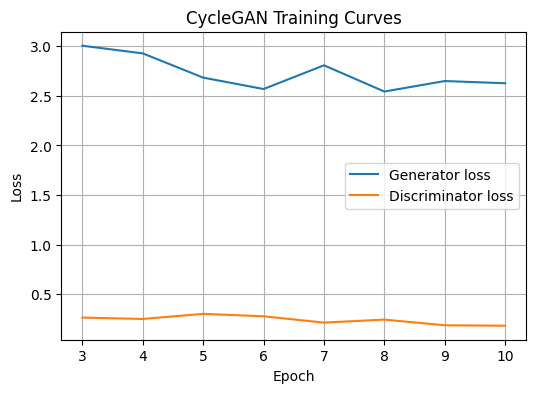

In [16]:
# ===== Cell 10: plot training curves =====
import matplotlib.pyplot as plt, json

path = WORK_DIR / "train_history.json"
if path.exists():
    hist = json.load(open(path))
    plt.figure(figsize=(6,4))
    plt.plot(hist["epoch"], hist["G_loss"], label="Generator loss")
    plt.plot(hist["epoch"], hist["D_loss"], label="Discriminator loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("CycleGAN Training Curves")
    plt.legend()
    plt.grid(True)
    plt.show()
else:
    print("No training history found at", path)


In [ ]:
# ===== Cell 11: manual export (run when you want a fresh ZIP) =====
export_checkpoints_zip("cyclegan_artifacts_now")
